In [80]:
#importing and setting up libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
import re
import nltk
from nltk.corpus import stopwords
from collections import Counter
from tqdm import tqdm
from scipy.stats import gaussian_kde
from collections import Counter
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap
from nltk.stem.snowball import SnowballStemmer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, roc_curve, classification_report
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
#loading the dataset and understanding the dataset 
df = pd.read_csv("C:/Users/LENOVO/OneDrive/Desktop/WELFake_Dataset.csv", index_col=0)

# Quick look at the data
print("Dataset shape:", df.shape)
print(df.head())

# Check column names
print("Columns:", df.columns)

Dataset shape: (72134, 3)
                                               title  \
0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1                                                NaN   
2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3  Bobby Jindal, raised Hindu, uses story of Chri...   
4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1  
Columns: Index(['title', 'text', 'label'], dtype='object')


In [3]:
#understanding the data because it makes life easier
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (72134, 3)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 72134 entries, 0 to 72133
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   71576 non-null  object
 1   text    72095 non-null  object
 2   label   72134 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.2+ MB
None

Missing Values:
title    558
text      39
label      0
dtype: int64


In [4]:
#adding word count and character count because we have less columns
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))
df["char_length"] = df["text"].astype(str).apply(len)

df.head()

,title,text,label,word_count,char_length
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,871,5049
1,NaN,Did they post their votes for Hillary already?,1,8,46
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,34,216
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,1321,8010
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,329,1916


In [5]:
#understanding the imbalance ratio 
def imbalance_ratio(df, target_col):
    class_counts = df[target_col].value_counts()
    majority = class_counts.max()
    minority = class_counts.min()
    IR = majority / minority
    
    print("Class counts:")
    print(class_counts)
    print("\nImbalance Ratio (IR): {:.2f}".format(IR))
    
    if IR <= 1.5:
        print("Dataset is Balanced.")
    elif IR <= 3:
        print("Mild Imbalance.")
    else:
        print("Strong Imbalance – resampling recommended.")
    
    return IR

# Call the function
imbalance_ratio(df, "label")


Class counts:
label
1    37106
0    35028
Name: count, dtype: int64

Imbalance Ratio (IR): 1.06
Dataset is Balanced.


np.float64(1.0593239693959118)

In [6]:
#standardizing and cleaning the column names 
df.columns = df.columns.str.lower().str.strip()

In [7]:
#to ensure the NLP pipeline always uses a clean and consistent text input, the below written code
#detetcts the correct text column in the dataset, and combines title and text when available
if set(["title", "text"]).issubset(df.columns):
    df["combined_text"] = (
        df["title"].fillna("") + " " + df["text"].fillna("")
    )
    text_col = "combined_text"
elif "text" in df_small.columns:
    text_col = "text"
elif "news" in df_small.columns:
    text_col = "news"
else:
    raise ValueError("No suitable text column found!")

In [8]:
#convering the entire text column into text format
df[text_col] = df[text_col].astype(str)

In [9]:
#removing duplicate text entries 
df.drop_duplicates(subset=[text_col], inplace=True)

In [10]:
#removing short and meaningless text because it does not containin meaningful information for TF-IDF
df = df[df[text_col].str.strip().str.len() > 20]

In [11]:
#creating a function clean_text to preprocess textual data. It lowercases text, removes URLs,
#removes URLs, and special characters, and normalizes spacing. The function is applied before modelling. 
def clean_text(text):
    """ Cleans the input text by:
    1. Converting to lowercase.
    2. Removing URLs. 
    3. Removing non-alphanumeric characters (except apostriphes and spaces). 
    4. Normalizing multiple spaces to a single space.
    """
    text = text.lower() #converting to lowercase
    text = re.sub(r"http\S+", " ", text) #removing URLs of any kind 
    text = re.sub(r"[^a-zA-Z0-9\' ]+", " ", text) #keeping only letters, numbers, apostrophes, and spaces
    text = re.sub(r"\s+", " ", text).strip() #normalizing soaces and removing leading and trailing spaces
    return text 

#applying text cleaning to the specified column 
df[text_col] = df[text_col].apply(clean_text)

In [12]:
#ensuring thr label column exists and converting it to the numeric format for machine learning 
if "label" in df.columns:
    df["label"] = df["label"].replace({
        "FAKE": 0, "fake": 0,
        "REAL": 1, "real": 1
    }).astype(int)  
else:
    raise ValueError("Label column missing!")

In [13]:
#checking data sanity after preprocessing 
print("\nShape of DataFrame after cleaning:", df.shape)
print(df.sample(5))


Shape of DataFrame after cleaning: (63633, 6)
                                                   title  \
59775  Fed up with Washington, Trump's 'deplorables' ...   
29203  Ukrainian MP offers more details on alleged pa...   
28949   Virginia Republicans Want To Verify Kids’ Gen...   
19051  Norway appoints its first female foreign minister   
16717  Ne supportant plus l’ambiance de la campagne é...   

                                                    text  label  word_count  \
59775  MIAMI/WASHINGTON (Reuters) - Fed up with Washi...      0         621   
29203  KIEV (Reuters) - A Ukrainian lawmaker on Frida...      0         421   
28949  Conservative Christian lawmakers in Virginia h...      1         413   
19051  OSLO (Reuters) - Norwegian Defence Minister In...      0          98   
16717                                                NaN      1           1   

       char_length                                      combined_text  
59775         3797  fed up with washington tr

In [14]:
#checking for missing values 
print("Missing Values Before Handling:")
print(df.isnull().sum())  # Count of missing values per column
print("\nTotal missing values in DataFrame:", df.isnull().sum().sum())

Missing Values Before Handling:
title            478
text              39
label              0
word_count         0
char_length        0
combined_text      0
dtype: int64

Total missing values in DataFrame: 517


In [15]:
text_col = (
    "combined_text" if "combined_text" in df.columns else
    "text" if "text" in df.columns else
    "news"
)

In [16]:
#handling missing text byb filling NaNs and removing the rows that are too short to provide meaningful information 
df[text_col] = df[text_col].fillna("")
df = df[df[text_col].str.strip().str.len() > 20]

In [17]:
#removing duplicates
df = df.drop_duplicates(subset=[text_col])
df = df.fillna("")

In [18]:
print("\n Missing Values After Handling:")
print(df.isnull().sum())
print("\nFinal Shape:", df.shape)


 Missing Values After Handling:
title            0
text             0
label            0
word_count       0
char_length      0
combined_text    0
dtype: int64

Final Shape: (63303, 6)


In [19]:
#counting the number of samples per label
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']

In [20]:
#mapping numeric labels to readable strings 
label_counts['Label'] = label_counts['Label'].map({0: 'Real', 1: 'Fake'})

In [21]:
#defining customer colours
custom_colors = ["#FFC0CB", "#E6E6FA"] 

In [22]:
#building a pie chart
fig = px.pie(
    label_counts,
    names='Label',
    values='Count',
    title="Label Distribution: Real vs Fake News",
    color='Label',
    color_discrete_sequence=custom_colors,
    hole=0.3
)

In [23]:
fig.update_traces(
    textinfo='percent+label',  # Show both percent and label
    textfont_size=16,
    pull=[0.05, 0.05]          # Slightly pull slices
)

fig.update_layout(
    title_font=dict(size=26, color="#353839", family="Helvetica"),
    legend_title_font=dict(size=16),
    template="plotly_white"
)

In [24]:
#computing histogram of character lengths 
counts, bins = np.histogram(df["char_length"], bins=50)
bin_mid = 0.5 * (bins[1:] + bins[:-1])

In [27]:
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

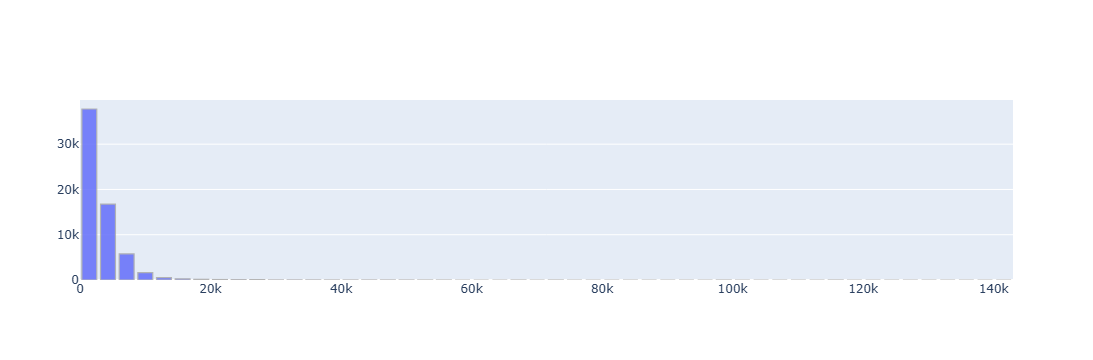

In [30]:
fig = go.Figure()
fig.add_trace(go.Bar(
    x=bin_mid,
    y=counts,
    marker_line_color="#A9A9A9",
    marker_line_width=1.2,
    opacity=0.85,
    hovertemplate='Text Length: %{x}<br>Count: %{y}<extra></extra>'
))

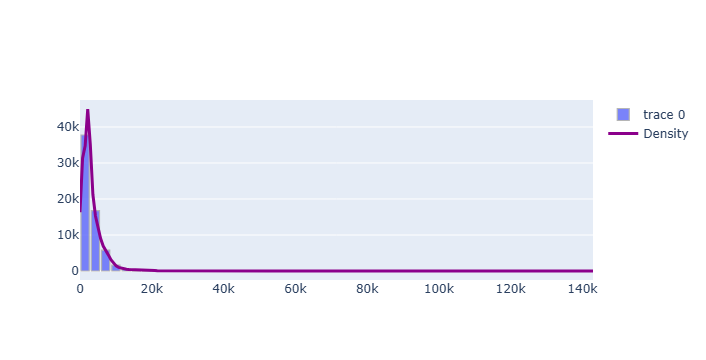

In [31]:
# Overlay Gaussian KDE density curve
kde = gaussian_kde(df["char_length"])
x_kde = np.linspace(df["char_length"].min(), df["char_length"].max(), 200)
fig.add_trace(go.Scatter(
    x=x_kde,
    y=kde(x_kde) * len(df) * (bins[1]-bins[0]),
    mode='lines',
    line=dict(color="#8B008B", width=3),  # deep purple for contrast
    name="Density"
))

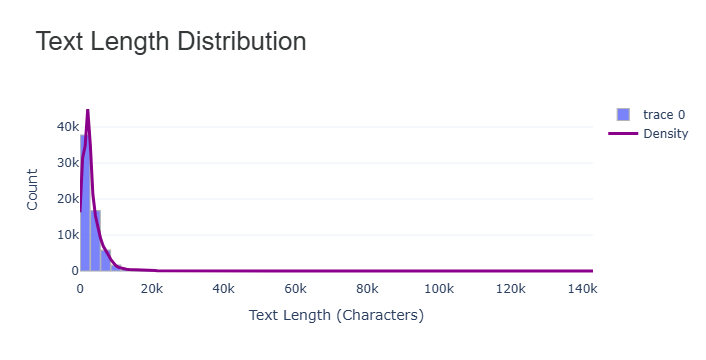

In [32]:
fig.update_layout(
    title="Text Length Distribution",
    template="plotly_white",
    title_font=dict(size=26, family="Helvetica", color="#353839"),
    xaxis_title="Text Length (Characters)",
    yaxis_title="Count",
    bargap=0.05,
    plot_bgcolor="white",
    showlegend=True
)

fig.show()

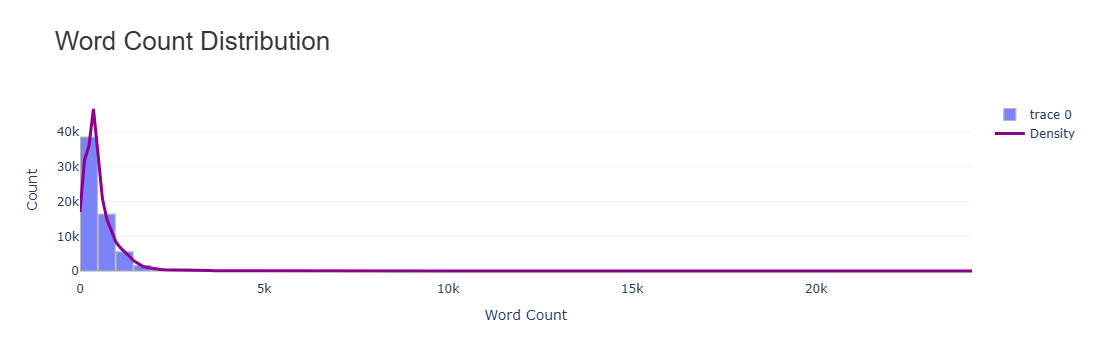

In [34]:
#word count distribution 
counts, bins = np.histogram(df["word_count"], bins=50)
bin_mid = 0.5 * (bins[1:] + bins[:-1])
def hex_to_rgb(hex_color):
    hex_color = hex_color.lstrip('#')
    return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
fig = go.Figure()
fig.add_trace(go.Bar(
    x=bin_mid,
    y=counts,
    marker_line_color="#A9A9A9",
    marker_line_width=1.2,
    opacity=0.85,
    hovertemplate='Word Count: %{x}<br>Count: %{y}<extra></extra>'
))
kde = gaussian_kde(df["word_count"])
x_kde = np.linspace(df["word_count"].min(), df["word_count"].max(), 200)
fig.add_trace(go.Scatter(
    x=x_kde,
    y=kde(x_kde) * len(df) * (bins[1]-bins[0]),
    mode='lines',
    line=dict(color="#8B008B", width=3),  # deep purple for contrast
    name="Density"
))
fig.update_layout(
    title="Word Count Distribution",
    template="plotly_white",
    title_font=dict(size=26, family="Helvetica", color="#353839"),
    xaxis_title="Word Count",
    yaxis_title="Count",
    bargap=0.05,
    plot_bgcolor="white",
    showlegend=True
)

fig.show()

In [35]:
#finding top 20 common words
all_text = " ".join(df[text_col].tolist())
all_text = re.sub(r"[^a-zA-Z\s]", "", all_text)
words = all_text.lower().split()
word_counts = Counter(words)
common_words = pd.DataFrame(word_counts.items(), columns=["word", "count"])
common_words = common_words.sort_values(by="count", ascending=False).head(20).reset_index(drop=True)
common_words

,word,count
0,the,1988780
1,to,995828
2,of,881168
3,and,809536
4,a,804505
5,in,691112
6,that,469958
7,s,458506
8,on,335031
9,is,333976


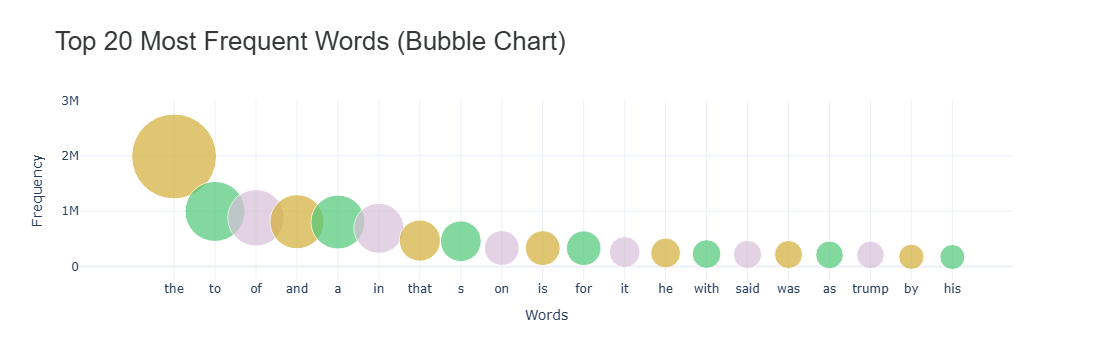

In [41]:
common_words['size'] = common_words['count'] 
lux_colors = ["#D4AF37", "#50C878", "#D8BFD8"]  
colors = [lux_colors[i % len(lux_colors)] for i in range(len(common_words))]
fig = px.scatter(
    common_words,
    x='word',
    y='count',
    size='size',
    color='word',
    color_discrete_sequence=colors,
    size_max=60,
    title="Top 20 Most Frequent Words (Bubble Chart)"
)

fig.update_layout(
    template="plotly_white",
    title_font=dict(size=26, family="Helvetica", color="#353839"),
    xaxis_title="Words",
    yaxis_title="Frequency",
    showlegend=False
)

fig.show()

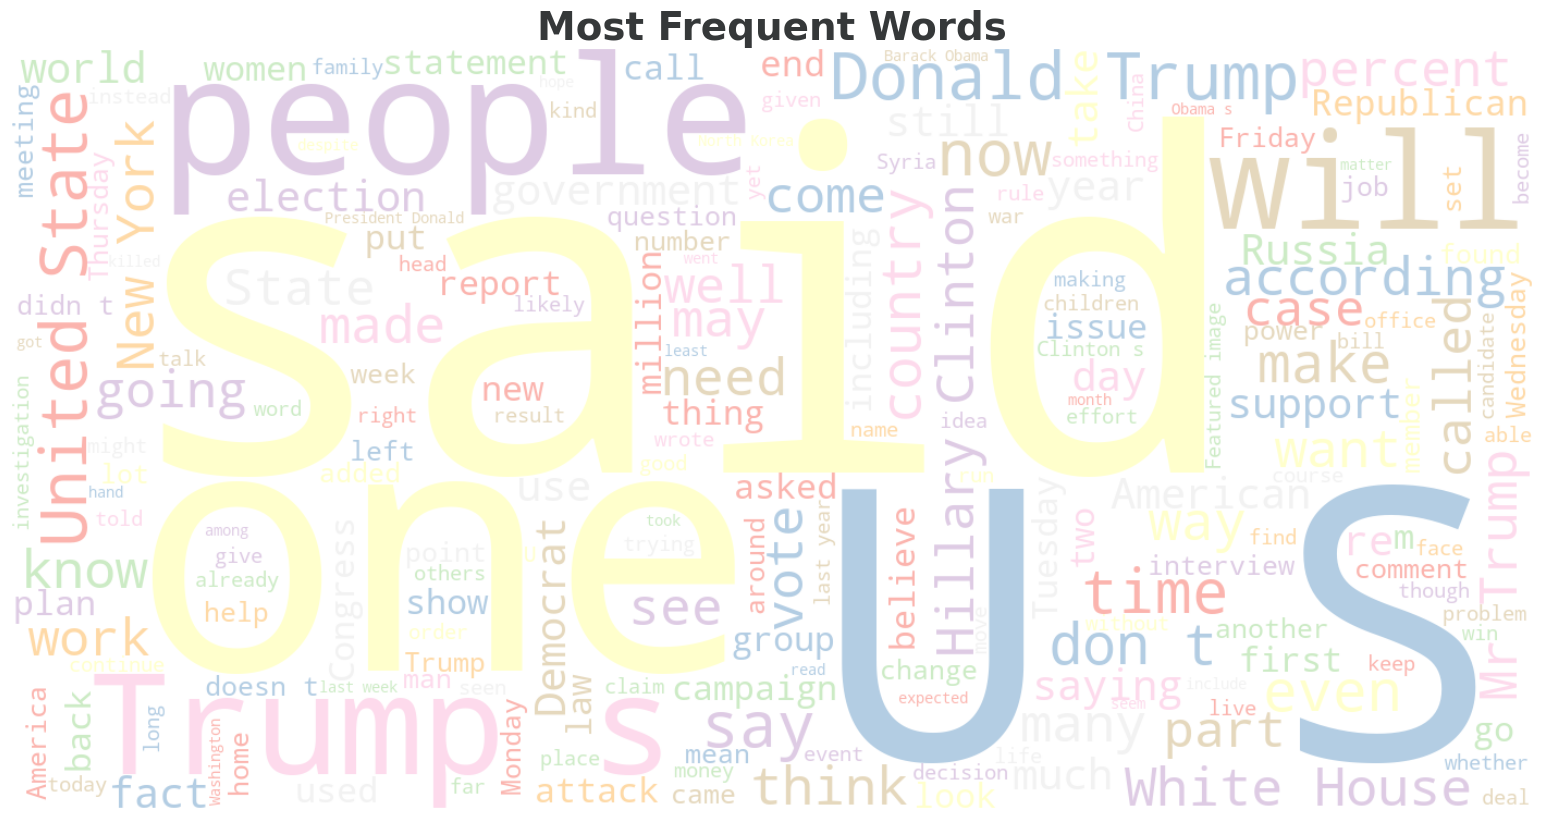

In [42]:
text_joined = " ".join(df['text'].astype(str).tolist())
wc = WordCloud(
    width=1400,
    height=700,
    background_color="white",
    colormap="Pastel1",  
    max_words=200,
    contour_width=1,
    contour_color="#353839",  
    prefer_horizontal=0.9,
    random_state=42
).generate(text_joined)
plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words", fontsize=28, fontweight='bold', color="#353839")
plt.tight_layout(pad=0)
plt.show()

In [46]:
class TextCleaner(BaseEstimator, TransformerMixin):
    """
    TextCleaner: Scikit-learn compatible transformer for NLP preprocessing.
    
    Features:
    - Converts text to lowercase.
    - Removes URLs, digits, punctuation, emojis, and special characters.
    - Removes English stopwords.
    - Applies Snowball stemming.
    - Removes very short words (length <= 2).
    - Returns cleaned text suitable for vectorization or modeling.
    
    Can be used directly in scikit-learn pipelines.
    """

    def __init__(self):
        self.stop_words = set(stopwords.words("english"))
        self.stemmer = SnowballStemmer("english")
        self.url_pattern = re.compile(r"http\S+|www\S+|https\S+")
        self.non_alpha_pattern = re.compile(r"[^a-z\s]")  
    def clean_text(self, text):
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = self.url_pattern.sub(" ", text)
        text = self.non_alpha_pattern.sub(" ", text)
        tokens = text.split()
        cleaned_tokens = [
            self.stemmer.stem(word)
            for word in tokens
            if word not in self.stop_words and len(word) > 2
        ]
        return " ".join(cleaned_tokens).strip()
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return pd.Series([self.clean_text(text) for text in X], index=X.index)

In [49]:
cleaner = TextCleaner()
df["text_clean"] = cleaner.transform(df["text"])

In [50]:
demo_df = df[["text", "text_clean"]].head(10)
demo_df

,text,text_clean
0,No comment is expected from Barack Obama Membe...,comment expect barack obama member fyf fukyofl...
1,Did they post their votes for Hillary already?,post vote hillari alreadi
2,"Now, most of the demonstrators gathered last ...",demonstr gather last night exercis constitut p...
3,A dozen politically active pastors came here f...,dozen polit activ pastor came privat dinner fr...
4,"The RS-28 Sarmat missile, dubbed Satan 2, will...",sarmat missil dub satan replac fli mile per se...
5,All we can say on this one is it s about time ...,say one time someon su southern poverti law ce...
6,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,ben carson tell stori happen spoke obama
7,,
8,"The owner of the Ringling Bar, located south o...",owner ringl bar locat south white sulphur spri...
9,"FILE – In this Sept. 15, 2005 file photo, the ...",file sept file photo marker welcom commut cush...


In [51]:
df = df[df["text_clean"].str.strip() != ""]
df = df.dropna(subset=["text_clean"]).reset_index(drop=True)

print(f"Remaining data after cleaning empty rows: {len(df)} samples\n")

Remaining data after cleaning empty rows: 62676 samples



In [53]:
#deifiniing features
X = df["text_clean"]
y = df["label"]

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,           
    random_state=42,          
    stratify=y                
)

In [56]:
print(" Dataset Split Summary")

print("Training samples :", len(X_train))
print("Test samples     :", len(X_test))

print("\n Label distribution (Training)")
print(y_train.value_counts(normalize=True).rename("proportion"))

print("\n Label distribution (Test)")
print(y_test.value_counts(normalize=True).rename("proportion"))

 Dataset Split Summary
Training samples : 50140
Test samples     : 12536

 Label distribution (Training)
label
0    0.550738
1    0.449262
Name: proportion, dtype: float64

 Label distribution (Test)
label
0    0.550734
1    0.449266
Name: proportion, dtype: float64


In [64]:
import time
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from nltk.corpus import stopwords
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

In [58]:
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1,2),            
    min_df=3,
    max_df=0.90
)

print("TF-IDF Vectorizer initialized!\n")


TF-IDF Vectorizer initialized!



In [59]:
svm_pipeline = Pipeline([
    ("cleaner", TextCleaner()),
    ("tfidf", tfidf),
    ("clf", LinearSVC())
])

nb_pipeline = Pipeline([
    ("cleaner", TextCleaner()),
    ("tfidf", tfidf),
    ("clf", MultinomialNB())
])

print("SVM & Naive Bayes pipelines built successfully!\n")

SVM & Naive Bayes pipelines built successfully!



In [60]:
print("Sanity check: Running quick 1000-sample training test...\n")

sample_X = X_train.head(1000)
sample_y = y_train.head(1000)

Sanity check: Running quick 1000-sample training test...



In [61]:
start = time.time()
svm_pipeline.fit(sample_X, sample_y)
svm_time = time.time() - start
print(f"SVM sample training complete in {svm_time:.2f} seconds")

SVM sample training complete in 2.85 seconds


In [62]:
start = time.time()
nb_pipeline.fit(sample_X, sample_y)
nb_time = time.time() - start
print(f" Naive Bayes sample training complete in {nb_time:.2f} seconds\n")

 Naive Bayes sample training complete in 2.72 seconds



In [63]:
print("Pipeline Summary")

print("Linear SVM pipeline:")
print(svm_pipeline)

print("\nMultinomial Naive Bayes pipeline:")
print(nb_pipeline)


Pipeline Summary
Linear SVM pipeline:
Pipeline(steps=[('cleaner', TextCleaner()),
                ('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=12000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf', LinearSVC())])

Multinomial Naive Bayes pipeline:
Pipeline(steps=[('cleaner', TextCleaner()),
                ('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=12000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf', MultinomialNB())])


In [65]:
print("\n Starting Hyperparameter Tuning...\n")


 Starting Hyperparameter Tuning...



In [66]:
svm_param_grid = {
    "tfidf__max_features": randint(8000, 20000),
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__C": uniform(0.5, 3.0)      
}

nb_param_grid = {
    "tfidf__max_features": randint(8000, 20000),
    "tfidf__ngram_range": [(1,1), (1,2)],
    "clf__alpha": uniform(0.0, 2.0)  
}

print("Parameter grids created.\n")

Parameter grids created.



In [67]:
from sklearn.model_selection import RandomizedSearchCV

print("\n Starting FAST SVM hyperparameter tuning...\n")


 Starting FAST SVM hyperparameter tuning...



In [70]:
#prevectorizing data such that CV does not recompute TF-IDF every fold 
vectorizer = TfidfVectorizer(
    max_features=8000,        
    ngram_range=(1, 2)
)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

In [71]:
#SVM Model and parameters
svm = LinearSVC()

svm_param_grid = {
    "C": [0.05, 0.1, 0.5, 1, 2, 5],
    "loss": ["hinge", "squared_hinge"],
}


In [72]:
svm_search = RandomizedSearchCV(
    estimator=svm,
    param_distributions=svm_param_grid,
    n_iter=6,             
    scoring="f1",
    cv=2,                 
    n_jobs=1,             
    verbose=2
)
start_time = time.time()
svm_search.fit(X_train_vec, y_train)
svm_tuning_time = time.time() - start_time

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV] END .................................C=0.05, loss=hinge; total time=   0.2s
[CV] END .................................C=0.05, loss=hinge; total time=   0.1s
[CV] END ..........................C=0.5, loss=squared_hinge; total time=   0.8s
[CV] END ..........................C=0.5, loss=squared_hinge; total time=   0.7s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.6s
[CV] END ..........................C=0.1, loss=squared_hinge; total time=   0.6s
[CV] END ....................................C=2, loss=hinge; total time=   1.7s
[CV] END ....................................C=2, loss=hinge; total time=   1.4s
[CV] END ............................C=5, loss=squared_hinge; total time=   1.1s
[CV] END ............................C=5, loss=squared_hinge; total time=   1.1s
[CV] END ....................................C=1, loss=hinge; total time=   0.5s
[CV] END ....................................C=1,

In [74]:
print("\nSVM tuning completed!")
print(f"Total time: {svm_tuning_time:.2f} seconds")
print("\nBest SVM Parameters:", svm_search.best_params_)
print("Best Cross-Validated F1 Score:", svm_search.best_score_)


SVM tuning completed!
Total time: 13.57 seconds

Best SVM Parameters: {'loss': 'squared_hinge', 'C': 0.5}
Best Cross-Validated F1 Score: 0.9353304409077905


In [75]:
best_svm = svm_search.best_estimator_

print("\nSVM model ready for evaluation.\n")


SVM model ready for evaluation.




Starting SVM Model Evaluation...

Accuracy: 0.9520
F1-score: 0.9465
ROC-AUC: 0.9902


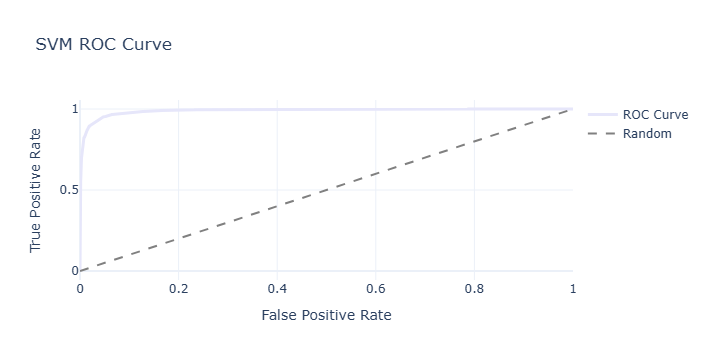

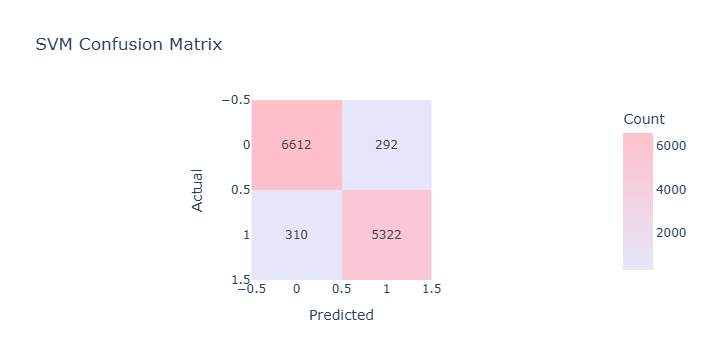

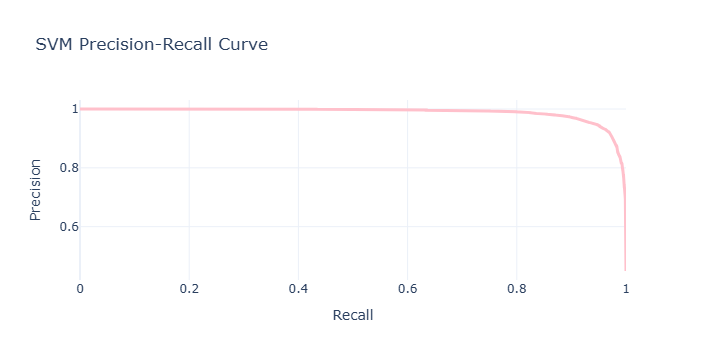


Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      6904
           1       0.95      0.94      0.95      5632

    accuracy                           0.95     12536
   macro avg       0.95      0.95      0.95     12536
weighted avg       0.95      0.95      0.95     12536



In [79]:
#starting SVM Model evaluation
print("\nStarting SVM Model Evaluation...\n")
y_pred = best_svm.predict(X_test_vec)
y_scores = best_svm.decision_function(X_test_vec)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
roc_auc = roc_auc_score(y_test, y_scores)
print(f"ROC-AUC: {roc_auc:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC Curve', line=dict(color='lavender', width=3)))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(color='gray', dash='dash')))
fig_roc.update_layout(
    title='SVM ROC Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_white'
)
fig_roc.show()
cm = confusion_matrix(y_test, y_pred)
cm_fig = px.imshow(
    cm,
    text_auto=True,
    color_continuous_scale=['lavender','pink'],
    labels=dict(x="Predicted", y="Actual", color="Count"),
    title="SVM Confusion Matrix"
)
cm_fig.show()
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_scores)
fig_pr = go.Figure()
fig_pr.add_trace(go.Scatter(x=recall, y=precision, mode='lines', line=dict(color='pink', width=3), name='Precision-Recall'))
fig_pr.update_layout(
    title='SVM Precision-Recall Curve',
    xaxis_title='Recall',
    yaxis_title='Precision',
    template='plotly_white'
)
fig_pr.show()
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [83]:
print("\n Building Naive Bayes Pipeline and tuning...\n")
vectorizer_nb = TfidfVectorizer(
    max_features=8000,      
    ngram_range=(1,2)
)
X_train_vec_nb = vectorizer_nb.fit_transform(X_train)
X_test_vec_nb  = vectorizer_nb.transform(X_test)
nb_model = MultinomialNB()
nb_param_grid = {
    "alpha": [0.1, 0.5, 1.0, 1.5, 2.0]  
}
nb_search = RandomizedSearchCV(
    estimator=nb_model,
    param_distributions=nb_param_grid,
    n_iter=5,         
    scoring="f1",
    cv=2,             
    n_jobs=1,         
    verbose=1,
    random_state=42
)
start = time.time()
nb_search.fit(X_train_vec_nb, y_train)
nb_tuning_time = time.time() - start
print("\n Naive Bayes tuning completed!")
print(f" Time taken: {nb_tuning_time:.2f} sec")
print(" Best alpha:", nb_search.best_params_['alpha'])
print(" Best CV F1 Score:", nb_search.best_score_)
best_nb = nb_search.best_estimator_


 Building Naive Bayes Pipeline and tuning...

Fitting 2 folds for each of 5 candidates, totalling 10 fits

 Naive Bayes tuning completed!
 Time taken: 1.23 sec
 Best alpha: 0.1
 Best CV F1 Score: 0.8347716278732764


Starting Naive Bayes Model Evaluation...

Accuracy: 0.8460
F1-score: 0.8339
ROC-AUC: 0.9285


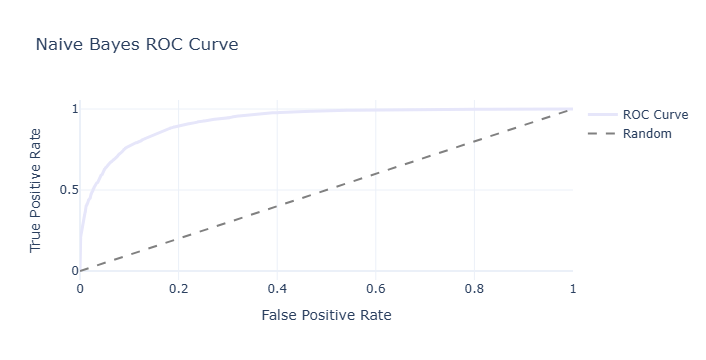

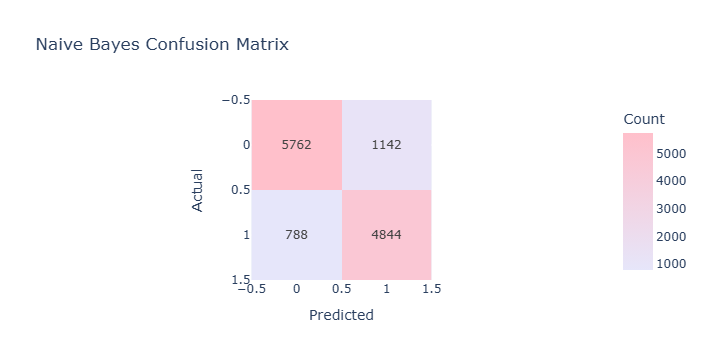

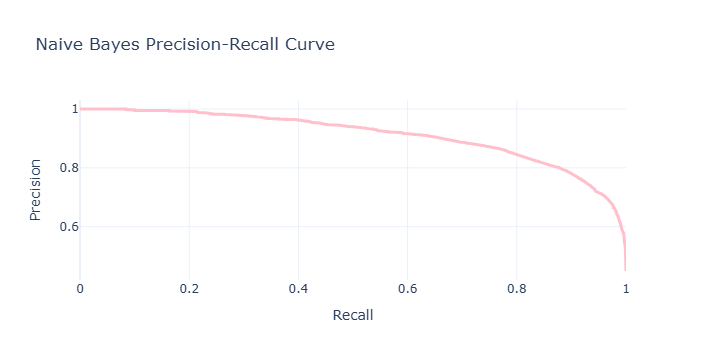

In [85]:
print("Starting Naive Bayes Model Evaluation...\n")
y_pred_nb = best_nb.predict(X_test_vec_nb)
y_scores_nb = best_nb.predict_proba(X_test_vec_nb)[:, 1]
acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
print(f"Accuracy: {acc_nb:.4f}")
print(f"F1-score: {f1_nb:.4f}")
roc_auc_nb = roc_auc_score(y_test, y_scores_nb)
print(f"ROC-AUC: {roc_auc_nb:.4f}")
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test, y_scores_nb)
fig_roc_nb = go.Figure()
fig_roc_nb.add_trace(go.Scatter(x=fpr_nb, y=tpr_nb, mode='lines', name='ROC Curve', line=dict(color='lavender', width=3)))
fig_roc_nb.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random', line=dict(color='gray', dash='dash')))
fig_roc_nb.update_layout(
    title='Naive Bayes ROC Curve',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    template='plotly_white'
)
fig_roc_nb.show()
#confusion matrix 
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_fig_nb = px.imshow(
    cm_nb,
    text_auto=True,
    color_continuous_scale=['lavender','pink'],
    labels=dict(x="Predicted", y="Actual", color="Count"),
    title="Naive Bayes Confusion Matrix"
)
cm_fig_nb.show()
precision_nb, recall_nb, pr_thresholds_nb = precision_recall_curve(y_test, y_scores_nb)
fig_pr_nb = go.Figure()
fig_pr_nb.add_trace(go.Scatter(x=recall_nb, y=precision_nb, mode='lines', line=dict(color='pink', width=3), name='Precision-Recall'))
fig_pr_nb.update_layout(
    title='Naive Bayes Precision-Recall Curve',
    xaxis_title='Recall',
    yaxis_title='Precision',
    template='plotly_white'
)
fig_pr_nb.show()

In [86]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))


Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.83      0.86      6904
           1       0.81      0.86      0.83      5632

    accuracy                           0.85     12536
   macro avg       0.84      0.85      0.85     12536
weighted avg       0.85      0.85      0.85     12536



In [87]:
#model comparison
model_comparison = pd.DataFrame({
    "Model": ["Linear SVM", "Naive Bayes"],
    "Accuracy": [acc, acc_nb],
    "F1-score": [f1, f1_nb],
    "ROC-AUC": [roc_auc, roc_auc_nb],
    "Tuning Time (s)": [svm_tuning_time, nb_tuning_time],
    "Best Hyperparameters": [svm_search.best_params_, nb_search.best_params_]
})

print("\nModel Comparison Table:")
display(model_comparison)


Model Comparison Table:


,Model,Accuracy,F1-score,ROC-AUC,Tuning Time (s),Best Hyperparameters
0,Linear SVM,0.951978,0.946470,0.990206,13.568255,"{'loss': 'squared_hinge', 'C': 0.5}"
1,Naive Bayes,0.846043,0.833878,0.928453,1.229477,{'alpha': 0.1}


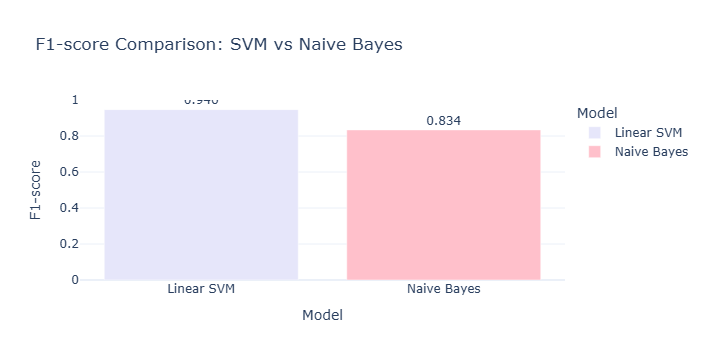

In [88]:
#F-1 score
fig_f1 = px.bar(
    model_comparison,
    x="Model",
    y="F1-score",
    text="F1-score",
    color="Model",
    color_discrete_map={"Linear SVM":"lavender","Naive Bayes":"pink"},
    title="F1-score Comparison: SVM vs Naive Bayes"
)
fig_f1.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_f1.update_layout(template="plotly_white", yaxis=dict(range=[0,1]))
fig_f1.show()

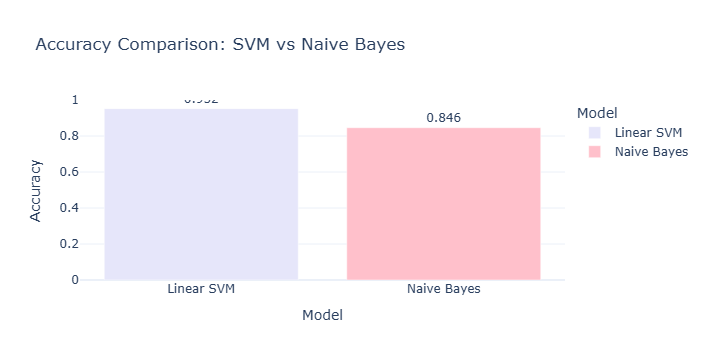

In [89]:
#Accuracy
fig_acc = px.bar(
    model_comparison,
    x="Model",
    y="Accuracy",
    text="Accuracy",
    color="Model",
    color_discrete_map={"Linear SVM":"lavender","Naive Bayes":"pink"},
    title="Accuracy Comparison: SVM vs Naive Bayes"
)
fig_acc.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_acc.update_layout(template="plotly_white", yaxis=dict(range=[0,1]))
fig_acc.show()

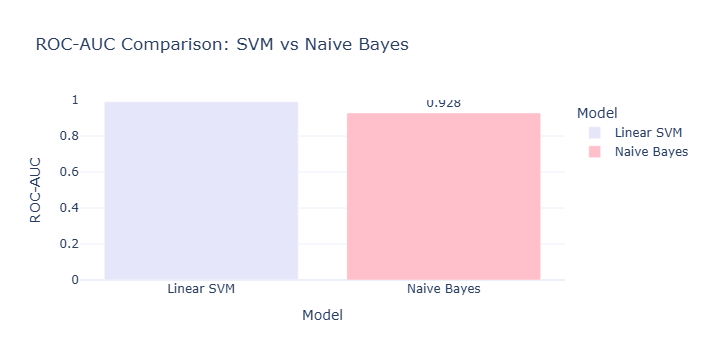

In [90]:
#roc-auc cuve
fig_rocauc = px.bar(
    model_comparison,
    x="Model",
    y="ROC-AUC",
    text="ROC-AUC",
    color="Model",
    color_discrete_map={"Linear SVM":"lavender","Naive Bayes":"pink"},
    title="ROC-AUC Comparison: SVM vs Naive Bayes"
)
fig_rocauc.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_rocauc.update_layout(template="plotly_white", yaxis=dict(range=[0,1]))
fig_rocauc.show()

Calculating extended evaluation metrics...


Extended Evaluation Metrics Table:


,Model,Accuracy,F1-score,ROC-AUC,Cohen's Kappa,Sensitivity,Specificity
0,Linear SVM,0.951978,0.946470,0.990206,0.902929,0.944957,0.957706
1,Naive Bayes,0.846043,0.833878,0.928453,0.690675,0.860085,0.834589


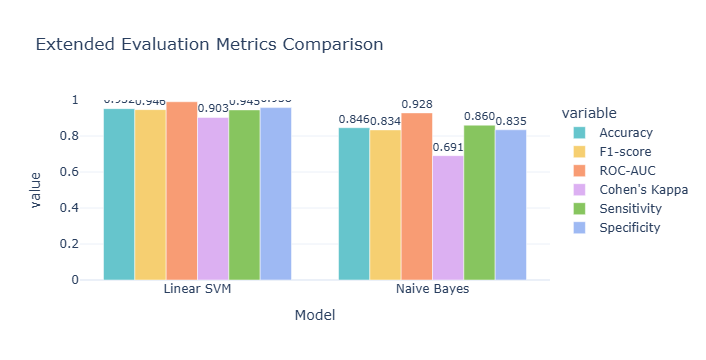

In [91]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix

print("Calculating extended evaluation metrics...\n")
cm_svm = confusion_matrix(y_test, y_pred)
cm_nb  = confusion_matrix(y_test, y_pred_nb)
def get_sens_spec(cm):
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn)      
    specificity = tn / (tn + fp)
    return sensitivity, specificity
kappa_svm = cohen_kappa_score(y_test, y_pred)
sens_svm, spec_svm = get_sens_spec(cm_svm)
kappa_nb = cohen_kappa_score(y_test, y_pred_nb)
sens_nb, spec_nb = get_sens_spec(cm_nb)
multi_metrics_df = pd.DataFrame({
    "Model": ["Linear SVM", "Naive Bayes"],
    "Accuracy": [acc, acc_nb],
    "F1-score": [f1, f1_nb],
    "ROC-AUC": [roc_auc, roc_auc_nb],
    "Cohen's Kappa": [kappa_svm, kappa_nb],
    "Sensitivity": [sens_svm, sens_nb],
    "Specificity": [spec_svm, spec_nb]
})

print("\nExtended Evaluation Metrics Table:")
display(multi_metrics_df)
metrics_to_plot = ["Accuracy", "F1-score", "ROC-AUC", "Cohen's Kappa", "Sensitivity", "Specificity"]
fig_metrics = px.bar(
    multi_metrics_df.melt(id_vars="Model", value_vars=metrics_to_plot),
    x="Model",
    y="value",
    color="variable",
    barmode="group",
    text="value",
    title="Extended Evaluation Metrics Comparison",
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig_metrics.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig_metrics.update_layout(template="plotly_white", yaxis=dict(range=[0,1]))
fig_metrics.show()

In [92]:
import shap
import matplotlib.pyplot as plt
import numpy as np

print("Starting SHAP Explainability for SVM and Naive Bayes...\n")

Starting SHAP Explainability for SVM and Naive Bayes...



In [93]:
import shap
explainer_svm = shap.LinearExplainer(best_svm, shap.maskers.Independent(X_train_vec))
shap_values_svm = explainer_svm.shap_values(X_test_vec)
coef_nb_derived = best_nb.feature_log_prob_[1, :] - best_nb.feature_log_prob_[0, :]
intercept_nb_derived = best_nb.class_log_prior_[1] - best_nb.class_log_prior_[0]
explainer_nb = shap.LinearExplainer((coef_nb_derived, intercept_nb_derived), shap.maskers.Independent(X_train_vec_nb))
shap_values_nb = explainer_nb.shap_values(X_test_vec_nb)

Top SHAP features for Linear SVM:


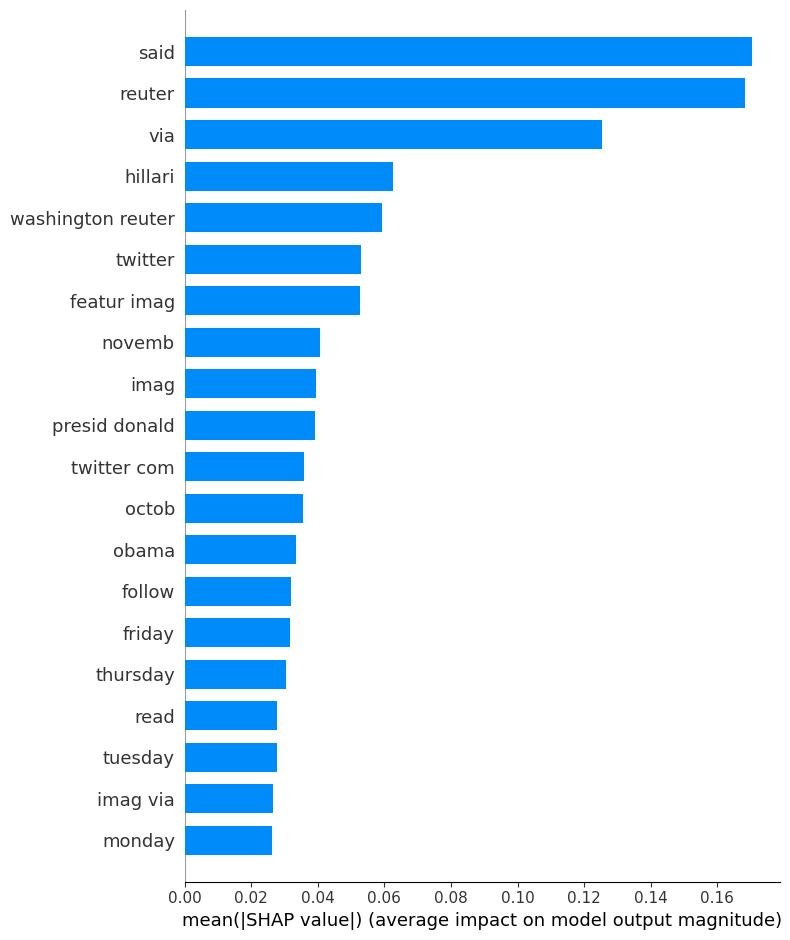

In [95]:
print("Top SHAP features for Linear SVM:")
shap.summary_plot(
    shap_values_svm,
    X_test_vec,
    feature_names=vectorizer.get_feature_names_out(),
    plot_type="bar",
    color_bar_label="Impact",
    show=True
)

Top SHAP features for Naive Bayes:


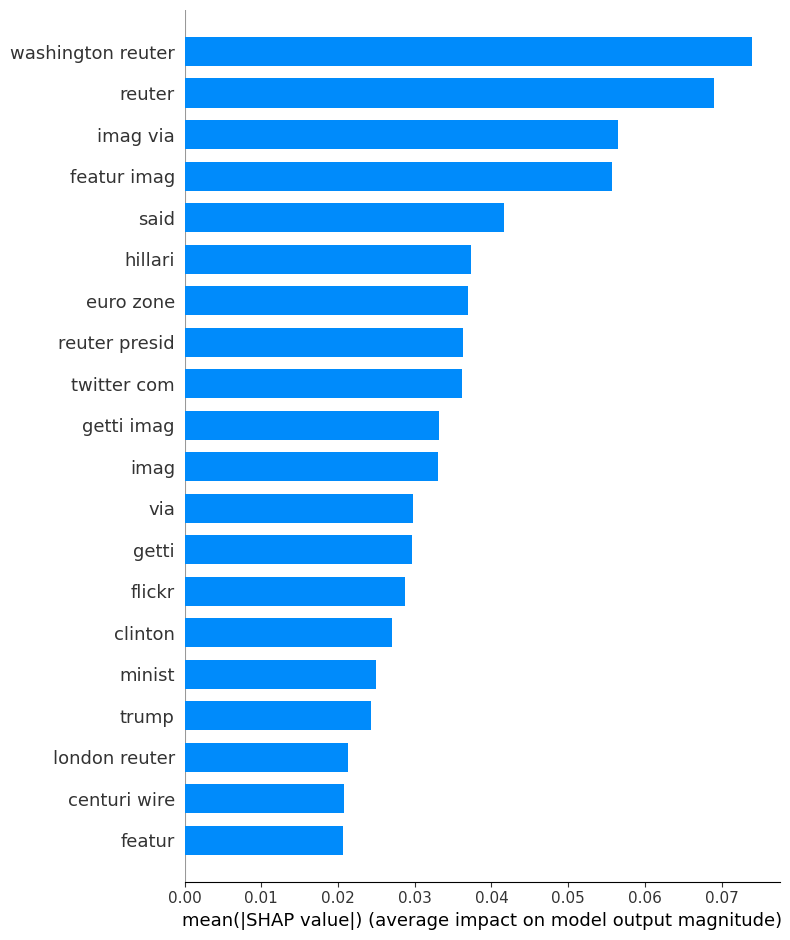

In [96]:
print("Top SHAP features for Naive Bayes:")
shap.summary_plot(
    shap_values_nb,
    X_test_vec_nb,
    feature_names=vectorizer_nb.get_feature_names_out(),
    plot_type="bar",
    color_bar_label="Impact",
    show=True
)